In [45]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import os
import sys
import pickle
import math
import matplotlib
from matplotlib.offsetbox import (TextArea, DrawingArea, OffsetImage,
                                  AnnotationBbox)

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

import neurolib.dashboard.data as data
from neurolib.models.aln import ALNModel
import neurolib.dashboard.layout as layout
import neurolib.dashboard.functions as functions
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import func_optimize as fo
from neurolib.utils import costFunctions as cost


# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2    

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
cmap = layout.getcolormap()
darkgrey, midgrey, lightgrey, color_bi_updown, color_LC, color_bi_uposc = layout.getcolors()
exc_red = cmap(3)
inh_blue=cmap(0)
green = cmap(2)

aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

facecolor_ = '#EAEAEA'
facecolor_ = 'white'

In [3]:
readpath = '..' + os.sep
savepath = os.path.join(os.getcwd().split('neurolib')[0], 'writing' + os.sep + 'paper1' + os.sep + 'concept' + os.sep + 'images')

with open(readpath + os.sep + 'bi.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc = load_array[0]
ext_inh = load_array[1]

grid_resolution = layout.grid_resolution

dist_up_regime = np.zeros((len(ext_exc), 2))
dist_down_regime = np.zeros((len(ext_exc)))

cmap = layout.getcolormap()
darkgrey, midgrey, lightgrey, color_bi_updown, color_LC, color_bi_uposc = layout.getcolors()
exc_red = cmap(3)
inh_blue=cmap(0)
green = cmap(2)

aln = ALNModel()
data.set_parameters(aln)
state_vars = aln.state_vars

In [4]:
##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]

def readcase(case_):
    
    global ind_, type_, mu_e, mu_i, a_e, a_i, cost_node, w_e, w_i, target_high, target_low 
    global d_e, d_i, d_total
    global cost_p_x, cost_p_y, cost_s_x, cost_s_y, cost_e_x, cost_e_y
    
    readpath = '..' + os.sep + 'data_final' + os.sep
    
    data_array = data.read_data_1(aln, readpath, case_)
    ind_, type_, mu_e, mu_i, a_e, a_i, cost_node, w_e, w_i, target_high, target_low = data_array
    
    opt_control = [None] * len(ind_)
    opt_state = [None] * len(ind_)
    
    control_data = data.read_control(readpath, case_)
    opt_control = control_data[2]
    opt_state = control_data[3]
        
    d_e = [None] * len(ind_)
    d_i = [None] * len(ind_)
    d_total = [None] * len(ind_)
    
    cost_p_x = [None] * len(ext_exc)
    cost_p_y = [None] * len(ext_exc)
    cost_s_x = [None] * len(ext_exc)
    cost_e_x = [None] * len(ext_exc)
    cost_s_y = [None] * len(ext_exc)
    cost_e_y = [None] * len(ext_exc)
    
    for i in ind_:
        
        if type(opt_control[i]) == type(None):
            continue
    
        if case_ in ['1', '2']:
            d_e[i] = data.dist_right(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_i[i] = data.dist_low(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_total[i] = data.dist_up_regime(mu_e[i], mu_i[i], boundary_exc_granular, boundary_inh_granular,
                                                   grid_resolution_granular)
        else:
            d_e[i] = data.dist_left(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_i[i] = data.dist_up(mu_e[i], mu_i[i], ext_exc_granular, ext_inh_granular, grid_resolution)
            d_total[i] = data.dist_down_regime(mu_e[i], mu_i[i], boundary_exc_granular, boundary_inh_granular,
                                               grid_resolution_granular)

            cost_p_x[i] = cost_node[i][0][0][0]
            cost_s_x[i] = cost_node[i][2][0][0]
            cost_e_x[i] = cost_node[i][1][0][0]
            cost_p_y[i] = cost_node[i][0][0][1]
            cost_s_y[i] = cost_node[i][2][0][1]
            cost_e_y[i] = cost_node[i][1][0][1]

In [5]:
ind0 = 20
readpath = '..' + os.sep + 'data_final'

control_data = data.read_control(readpath, '1')
opt_cntrl_1 = control_data[2][ind0][:,:,100:-100]
cost_node_1 = control_data[4][ind0]

control_data = data.read_control(readpath, '2')
opt_cntrl_2 = control_data[2][ind0][:,:,100:-100]
cost_node_2 = control_data[4][ind0]

control_data = data.read_control(readpath, '3')
opt_cntrl_3 = control_data[2][ind0][:,:,100:-100]
cost_node_3 = control_data[4][ind0]

control_data = data.read_control(readpath, '4')
opt_cntrl_4 = control_data[2][ind0][:,:,100:-100]
cost_node_4 = control_data[4][ind0]

data.set_parameters(aln)

aln.params.mue_ext_mean = ext_exc[ind0] * 5.
aln.params.mui_ext_mean = ext_inh[ind0] * 5.

print(ext_exc[ind0], ext_inh[ind0])
        
maxI = 3.          
aln.params.duration = 3000.
control0 = aln.getZeroControl()
control0 = functions.step_control(aln, maxI_ = maxI)
aln.run(control=control0)

aln.params.duration = dur
target_1 = aln.getZeroTarget()
target_1[:,0,:] = aln.rates_exc[0,-1] 
target_1[:,1,:] = aln.rates_inh[0,-1]

aln.params.duration = 3000.
control0 = aln.getZeroControl()
control0 = functions.step_control(aln, maxI_ = -maxI)
aln.run(control=control0)

initVars_1 = np.zeros(( len(state_vars) ))
for j in range(len(state_vars)):
    if aln.state[state_vars[j]].size == 1:
        initVars_1[j] = aln.state[state_vars[j]][0]
    else:
        initVars_1[j] = aln.state[state_vars[j]][0,-1]
        
maxI = -3.          
aln.params.duration = 3000.
control0 = aln.getZeroControl()
control0 = functions.step_control(aln, maxI_ = maxI)
aln.run(control=control0)

aln.params.duration = dur
target_3 = aln.getZeroTarget()
target_3[:,0,:] = aln.rates_exc[0,-1] 
target_3[:,1,:] = aln.rates_inh[0,-1]

aln.params.duration = 3000.
control0 = aln.getZeroControl()
control0 = functions.step_control(aln, maxI_ = -maxI)
aln.run(control=control0)

initVars_3 = np.zeros(( len(state_vars) ))
for j in range(len(state_vars)):
    if aln.state[state_vars[j]].size == 1:
        initVars_3[j] = aln.state[state_vars[j]][0]
    else:
        initVars_3[j] = aln.state[state_vars[j]][0,-1]
        
aln.params.duration = dur
t_sim = aln.params.duration
t_sim_pre = 0.
t_sim_post = 0.

case =  ../data_final 1
case =  ../data_final 2
case =  ../data_final 3
case =  ../data_final 4
0.4500000000000001 0.4750000000000002
optimal cost sparsity =  3.3312300786170534
optimal cost energy =  3.552056617539224


In [169]:
ind0 = 50
readpath = '..' + os.sep + 'data_final'

control_data = data.read_control(readpath, '1')
opt_cntrl_1b = control_data[2][ind0][:,:,100:-100]
cost_node_1b = control_data[4][ind0]

control_data = data.read_control(readpath, '2')
opt_cntrl_2b = control_data[2][ind0][:,:,100:-100]
cost_node_2b = control_data[4][ind0]

control_data = data.read_control(readpath, '3')
opt_cntrl_3b = control_data[2][ind0][:,:,100:-100]
cost_node_3b = control_data[4][ind0]

control_data = data.read_control(readpath, '4')
opt_cntrl_4b = control_data[2][ind0][:,:,100:-100]
cost_node_4b = control_data[4][ind0]

data.set_parameters(aln)

aln.params.mue_ext_mean = ext_exc[ind0] * 5.
aln.params.mui_ext_mean = ext_inh[ind0] * 5.

print(ext_exc[ind0], ext_inh[ind0])
        
maxI = 3.          
aln.params.duration = 3000.
control0 = aln.getZeroControl()
control0 = functions.step_control(aln, maxI_ = maxI)
aln.run(control=control0)

aln.params.duration = dur
target_1b = aln.getZeroTarget()
target_1b[:,0,:] = aln.rates_exc[0,-1] 
target_1b[:,1,:] = aln.rates_inh[0,-1]

aln.params.duration = 3000.
control0 = aln.getZeroControl()
control0 = functions.step_control(aln, maxI_ = -maxI)
aln.run(control=control0)

initVars_1b = np.zeros(( len(state_vars) ))
for j in range(len(state_vars)):
    if aln.state[state_vars[j]].size == 1:
        initVars_1b[j] = aln.state[state_vars[j]][0]
    else:
        initVars_1b[j] = aln.state[state_vars[j]][0,-1]
        
maxI = -3.          
aln.params.duration = 3000.
control0 = aln.getZeroControl()
control0 = functions.step_control(aln, maxI_ = maxI)
aln.run(control=control0)

aln.params.duration = dur
target_3b = aln.getZeroTarget()
target_3b[:,0,:] = aln.rates_exc[0,-1] 
target_3b[:,1,:] = aln.rates_inh[0,-1]

aln.params.duration = 3000.
control0 = aln.getZeroControl()
control0 = functions.step_control(aln, maxI_ = -maxI)
aln.run(control=control0)

initVars_3b = np.zeros(( len(state_vars) ))
for j in range(len(state_vars)):
    if aln.state[state_vars[j]].size == 1:
        initVars_3b[j] = aln.state[state_vars[j]][0]
    else:
        initVars_3b[j] = aln.state[state_vars[j]][0,-1]
        
aln.params.duration = dur
t_sim = aln.params.duration
t_sim_pre = 0.
t_sim_post = 0.

case =  ../data_final 1
case =  ../data_final 2
case =  ../data_final 3
case =  ../data_final 4
0.47500000000000014 0.6000000000000003


In [29]:
with open('DC_current.pickle','rb') as file:
    DC_current= pickle.load(file)

In [192]:
def setinit(model, initial_params_):
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        if (type(model.params[init_vars[iv]]) == np.float64 or type(model.params[init_vars[iv]]) == float):
            model.params[init_vars[iv]] = initial_params_[iv]
        elif model.params[init_vars[iv]].ndim == 2:
            model.params[init_vars[iv]][0,:] = initial_params_[iv]
        else:
            model.params[init_vars[iv]][0] = initial_params_[iv]


def plot_control_current(model, control_array, t_sim_, y_labelbox, initial_params_,
                         target_, cost_label, line_label, path_, filename_ = '', shading = False, transition_time_ = 0.,
                         precision_variables_ = [0,1], print_cost_ = True):
    
    dt = model.params.dt
    if model.name == "aln" or model.name == "aln-control":
        control_factor = model.params.C/1000.
    else:
        control_factor = 1.
        
    control_ = control_array[0][0]
        
    model.params.duration = (control_.shape[2] - 1.) * dt
    i1 = 0
    i2 = 0
    i3 = 0
    
    N = model.params.N
    T = control_.shape[2] - i1 - i2
        
    
    init_vars = model.init_vars

    output_vars = model.output_vars
    
    columns = 4
    rows = 2
            
    fig, ax = plt.subplots(rows, columns, figsize=(12, 5), facecolor=facecolor_, gridspec_kw={'height_ratios': [4, 3]})
    plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.0, hspace=0.0)
    y_labels_rates = ['Rates exc. [Hz]', 'Rates inh. [Hz]']
    sim_legend = ['Uncontrolled rate', 'Control', 'Control current']
    cntrl_time_legend = ['Control active', 'Precision penalized']
            
    n_colors = len(control_array)
    color_array = np.zeros(( 2 + len(control_array) ))
    color_array[0] = 0.0
    color_array[1] = 1.
    color_distance = 0.2
    color_array[2:] = np.linspace(color_array[0] + color_distance, color_array[1] - color_distance, n_colors)
    colors_ = cmap(color_array)
    ### 0: target, 1: uncontrolled rate, 2...: control inputs
        
    ##### PLOT TARGET
    i3 = i1 # plot full target
    
    model.run(control=model.getZeroControl())
    
    for target_ind in range(len(target_)):
        
        if (i2 == 0):
            ax[0,target_ind].plot(model.t[i3:], target_[target_ind][0,0,i3-i1:], '--', linewidth = 3, color=exc_red)
            ax[0,target_ind].plot(model.t[i3:], target_[target_ind][0,1,i3-i1:], '--', linewidth = 3, color=inh_blue)
        else:
            ax[0,target_ind].plot(model.t[i3:-i2], target_[target_ind][0,0,i3-i1:], '--', linewidth = 3, color=exc_red)
            ax[0,target_ind].plot(model.t[i3:-i2], target_[target_ind][0,1,i3-i1:], '--', linewidth = 3, color=inh_blue)
    
    ##################### go through all controls in control array 
    
    for c_ind in range(len(control_array)):


        for c_ind_2 in range(len(control_array[c_ind])):
            control_ = control_array[c_ind][c_ind_2]

            linewidth_ = 2.
            if c_ind_2 != 0:
                linewidth_ = 1.
        
            setinit(model, initial_params_[c_ind])
            model.run(control=control_)
            
            ax[0,c_ind].plot(model.t, model[output_vars[0]][0,:], linewidth=linewidth_, color=exc_red)
            ax[0,c_ind].plot(model.t, model[output_vars[1]][0,:], linewidth=linewidth_, color=inh_blue)                     
            ax[1,c_ind].plot(model.t, control_[0,0,:] * control_factor, linewidth=linewidth_, color=exc_red)
            ax[1,c_ind].plot(model.t, control_[0,1,:] * control_factor, linewidth=linewidth_, color=inh_blue)
            # divide by five to take into account capacitance
            
            
    #####################
    for j in range(columns):
        ax[0,j].axvspan(transition_time_ * t_sim_, t_sim_, facecolor='grey', alpha=0.2
                    , zorder=-1, hatch='///', edgecolor = 'grey')

    
    max_current = np.amax(control_array)
    min_current = np.amin(control_array)
    
    y_lims = [1.1 * min_current * control_factor, 1.1 * max_current * control_factor]
    
    fontsize_ = 18

    ylim_rates = max(np.amax(target_[0][0,1,:]) * 1.05, 105.)
    
    for i in range(columns):
        ax[0,i].set_xticks([])
        ax[1,i].set_yticks(np.arange(-0.2, 0.21, step=0.1))
        ax[1,i].set_ylim(y_lims)
        ax[0,i].set_yticks(np.arange(0., ylim_rates+5., step=50.))
        ax[0,i].set_ylim([-5., ylim_rates])
        ax[1,i].set_xlabel('t [ms]', fontsize=fontsize_) 
        for j in range(rows):
            ax[j,i].tick_params(axis='x', labelsize=fontsize_)
            ax[j,i].tick_params(axis='y', labelsize=fontsize_)
            ax[j,i].set_xlim([model.t[0],model.t[-1]])
            ax[j,i].grid(False)
            ax[j,i].axhline(y=0., color='grey', linestyle='-', zorder=-1, linewidth=1)
            if i != 0:
                ax[j,i].set_yticks([])
        
    ax[0,0].set_ylabel('Rates [Hz]', fontsize=fontsize_)      
    ax[1,0].set_ylabel('Control [nA]', fontsize=fontsize_)  
    
    legend_elements = [Line2D([], [], color=exc_red, linewidth=2, label=line_label[0]),
                  Line2D([], [], color=inh_blue, linewidth=2, label=line_label[1]),
                  Line2D([], [], color=exc_red, linewidth=1, label=line_label[2]),
                  Line2D([], [], color=inh_blue, linewidth=1, label=line_label[3]),
                  #Line2D([], [], color='grey', marker='s', markeredgecolor='grey', markersize=10, markerfacecolor='grey', alpha=0.2, linestyle='None', label='Precision penalized'),
                      ]

    fig.legend(handles=legend_elements, fontsize=fontsize_, loc='upper right', bbox_to_anchor=(1.23, y_labelbox), ncol = 1, 
              handletextpad=0.1, columnspacing=1., edgecolor='black')

    #cols = ['Low to high, sparsity', 'Low to high, energy', 'High to low, sparsity', 'High to low, energy']
    cols = ['Task 1', 'Task 2', 'Task 3', 'Task 4']
            
    for a, col in zip(ax[0,:], cols):
        a.annotate(col, xy=(0.5, 1.0), xytext=(0,5), xycoords='axes fraction', textcoords='offset points',
                   size=fontsize_, ha='center', va='baseline')

    fig.text(1.08, 0.975, cost_label, horizontalalignment='left', verticalalignment='top', transform=ax[0,3].transAxes, fontsize=fontsize_,
                bbox=dict(facecolor='none'))
    
    fig.tight_layout()
        
    plt.savefig(os.path.join(path_, filename_), bbox_inches='tight', facecolor=fig.get_facecolor(),
                edgecolor='none', dpi=600)
    plt.savefig(os.path.join(savepath, filename_), bbox_inches='tight', facecolor=fig.get_facecolor(),
                edgecolor='none', dpi=600)

In [173]:
opt_cost1 = cost_node_1[0][0,0] + cost_node_1[2][0,0] + cost_node_1[2][0,1]
opt_cost2 = cost_node_2[0][0,0] + cost_node_2[1][0,0] + cost_node_2[1][0,1]
opt_cost3 = cost_node_3[0][0,0] + cost_node_3[2][0,0] + cost_node_3[2][0,1]
opt_cost4 = cost_node_4[0][0,0] + cost_node_4[1][0,0] + cost_node_4[1][0,1]

DC_cost1 = 0.00
DC_cost2 = 0.00
DC_cost3 = 0.00
DC_cost4 = 0.00

label_a =( 'Point a \n\n' + 'Optimal control cost: \n{:.2f}'.format(opt_cost1) + ', {:.2f}'.format(opt_cost2) + ', {:.2f}'.format(opt_cost3) + ', {:.2f}'.format(opt_cost4)
            + '\n\nStep current cost: \n{:.2f}'.format(DC_cost1) + ', {:.2f}'.format(DC_cost2) + ', {:.2f}'.format(DC_cost3) + ', {:.2f}'.format(DC_cost4) )

opt_cost1b = cost_node_1b[0][0,0] + cost_node_1b[2][0,0] + cost_node_1b[2][0,1]
opt_cost2b = cost_node_2b[0][0,0] + cost_node_2b[1][0,0] + cost_node_2b[1][0,1]
opt_cost3b = cost_node_3b[0][0,0] + cost_node_3b[2][0,0] + cost_node_3b[2][0,1]
opt_cost4b = cost_node_4b[0][0,0] + cost_node_4b[1][0,0] + cost_node_4b[1][0,1]

DC_cost1b = 0.00
DC_cost2b = 0.00
DC_cost3b = 0.00
DC_cost4b = 0.00

label_b =( 'Point a \n\n' + 'Optimal control cost: \n{:.2f}'.format(opt_cost1b) + ', {:.2f}'.format(opt_cost2b) + ', {:.2f}'.format(opt_cost3b) + ', {:.2f}'.format(opt_cost4b)
            + '\n\nStep current cost: \n{:.2f}'.format(DC_cost1b) + ', {:.2f}'.format(DC_cost2b) + ', {:.2f}'.format(DC_cost3b) + ', {:.2f}'.format(DC_cost4b) )

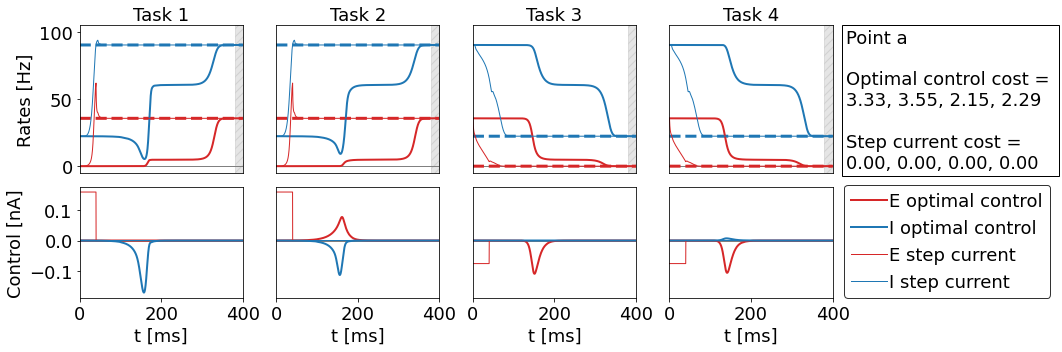

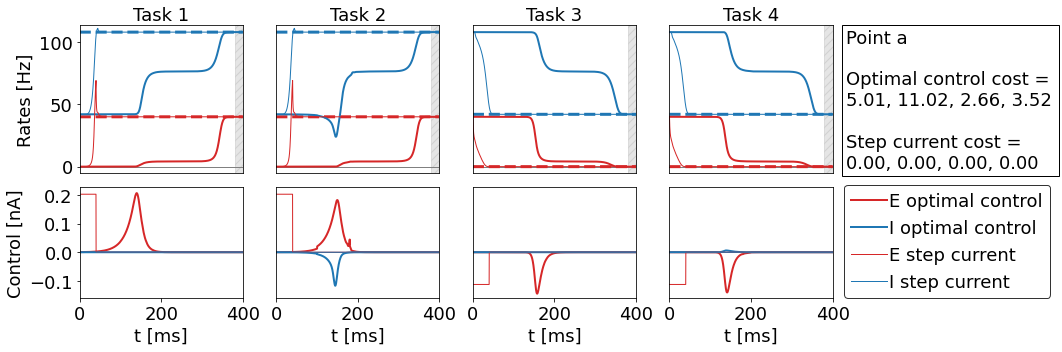

In [194]:
y_labelbox = 0.5
data.set_parameters(aln)
aln.params.mue_ext_mean = ext_exc[20] * 5.
aln.params.mui_ext_mean = ext_inh[20] * 5.

plot_control_current(aln, [[opt_cntrl_1, DC_current[0][0]], [opt_cntrl_2, DC_current[1][0]], [opt_cntrl_3, DC_current[2][0]], [opt_cntrl_4, DC_current[3][0]]],
            t_sim, y_labelbox,
            [initVars_1, initVars_1, initVars_3, initVars_3], [target_1, target_1, target_3, target_3],
            label_a, ['E optimal control', 'I optimal control', 'E step current', 'I step current'],
            path_=os.getcwd(), filename_ = 'DC_a.png', shading = False, transition_time_ = 0.95,
                    precision_variables_ = [0], print_cost_ = False)
plt.show()

data.set_parameters(aln)
aln.params.mue_ext_mean = ext_exc[50] * 5.
aln.params.mui_ext_mean = ext_inh[50] * 5.

plot_control_current(aln, [[opt_cntrl_1b, DC_current[0][1]], [opt_cntrl_2b, DC_current[1][1]], [opt_cntrl_3b, DC_current[2][1]], [opt_cntrl_4b, DC_current[3][1]]],
            t_sim, y_labelbox,
            [initVars_1b, initVars_1b, initVars_3b, initVars_3b], [target_1b, target_1b, target_3b, target_3b],
            label_b, ['E optimal control', 'I optimal control', 'E step current', 'I step current'],
            path_=os.getcwd(), filename_ = 'DC_b.png', shading = False, transition_time_ = 0.95,
                    precision_variables_ = [0], print_cost_ = False)
plt.show()

In [201]:
ind0 = [20, 50]
tasks = ['task1', 'task2', 'task3', 'task4']

opt_cntrl_min = [[None, None], [None, None], [None, None], [None, None]]
cost_node_min = [[None, None], [None, None], [None, None], [None, None]]

opt_cntrl_plus = [[None, None], [None, None], [None, None], [None, None]]
cost_node_plus = [[None, None], [None, None], [None, None], [None, None]]

for task_ind in range(len(tasks)):
    task = tasks[task_ind]

    readpath = '..' + os.sep + 'data_shift' + os.sep + task + os.sep + 'shift_-150'
    control_data = data.read_control(readpath, '')
    for j in range(len(ind0)):
        opt_cntrl_min[task_ind][j] = control_data[2][ind0[j]]
        cost_node_min[task_ind][j] = control_data[4][ind0[j]]
        
    readpath = '..' + os.sep + 'data_shift' + os.sep + task + os.sep + 'shift_+150'
    control_data = data.read_control(readpath, '')
    for j in range(len(ind0)):
        opt_cntrl_plus[task_ind][j] = control_data[2][ind0[j]]
        cost_node_plus[task_ind][j] = control_data[4][ind0[j]]

min_cost1a = cost_node_min[0][0][0][0,0] + cost_node_min[0][0][2][0,0] + cost_node_min[0][0][2][0,1]
min_cost2a = cost_node_min[1][0][0][0,0] + cost_node_min[1][0][1][0,0] + cost_node_min[1][0][1][0,1]
min_cost3a = cost_node_min[2][0][0][0,0] + cost_node_min[2][0][2][0,0] + cost_node_min[2][0][2][0,1]
min_cost4a = cost_node_min[3][0][0][0,0] + cost_node_min[3][0][1][0,0] + cost_node_min[3][0][1][0,1]

plus_cost1a = cost_node_plus[0][0][0][0,0] + cost_node_plus[0][0][2][0,0] + cost_node_plus[0][0][2][0,1]
plus_cost2a = cost_node_plus[1][0][0][0,0] + cost_node_plus[1][0][1][0,0] + cost_node_plus[1][0][1][0,1]
plus_cost3a = cost_node_plus[2][0][0][0,0] + cost_node_plus[2][0][2][0,0] + cost_node_plus[2][0][2][0,1]
plus_cost4a = cost_node_plus[3][0][0][0,0] + cost_node_plus[3][0][1][0,0] + cost_node_plus[3][0][1][0,1]

label_shift_a =( 'Point a \n\n' + 'Optimal control cost: \n{:.2f}'.format(opt_cost1) + ', {:.2f}'.format(opt_cost2) + ', {:.2f}'.format(opt_cost3) + ', {:.2f}'.format(opt_cost4)
            + '\n\nShift -150 ms cost: \n{:.2f}'.format(min_cost1a) + ', {:.2f}'.format(min_cost2a) + ', {:.2f}'.format(min_cost3a) + ', {:.2f}'.format(min_cost4a) 
            + '\nShift +150 ms cost: \n{:.2f}'.format(plus_cost1a) + ', {:.2f}'.format(plus_cost2a) + ', {:.2f}'.format(plus_cost3a) + ', {:.2f}'.format(plus_cost4a) )

min_cost1b = cost_node_min[0][1][0][0,0] + cost_node_min[0][1][2][0,0] + cost_node_min[0][1][2][0,1]
min_cost2b = cost_node_min[1][1][0][0,0] + cost_node_min[1][1][1][0,0] + cost_node_min[1][1][1][0,1]
min_cost3b = cost_node_min[2][1][0][0,0] + cost_node_min[2][1][2][0,0] + cost_node_min[2][1][2][0,1]
min_cost4b = cost_node_min[3][1][0][0,0] + cost_node_min[3][1][1][0,0] + cost_node_min[3][1][1][0,1]

plus_cost1b = cost_node_plus[0][1][0][0,0] + cost_node_plus[0][1][2][0,0] + cost_node_plus[0][1][2][0,1]
plus_cost2b = cost_node_plus[1][1][0][0,0] + cost_node_plus[1][1][1][0,0] + cost_node_plus[1][1][1][0,1]
plus_cost3b = cost_node_plus[2][1][0][0,0] + cost_node_plus[2][1][2][0,0] + cost_node_plus[2][1][2][0,1]
plus_cost4b = cost_node_plus[3][1][0][0,0] + cost_node_plus[3][1][1][0,0] + cost_node_plus[3][1][1][0,1]

label_shift_b =( 'Point b \n\n' + 'Optimal control cost: \n{:.2f}'.format(opt_cost1b) + ', {:.2f}'.format(opt_cost2b) + ', {:.2f}'.format(opt_cost3b) + ', {:.2f}'.format(opt_cost4b)
            + '\n\nShift -150 ms cost: \n{:.2f}'.format(min_cost1b) + ', {:.2f}'.format(min_cost2b) + ', {:.2f}'.format(min_cost3b) + ', {:.2f}'.format(min_cost4b) 
            + '\nShift +150 ms cost: \n{:.2f}'.format(plus_cost1b) + ', {:.2f}'.format(plus_cost2b) + ', {:.2f}'.format(plus_cost3b) + ', {:.2f}'.format(plus_cost4b) )

case =  ../data_shift/task1/shift_-150 
case =  ../data_shift/task1/shift_+150 
case =  ../data_shift/task2/shift_-150 
case =  ../data_shift/task2/shift_+150 
case =  ../data_shift/task3/shift_-150 
case =  ../data_shift/task3/shift_+150 
case =  ../data_shift/task4/shift_-150 
case =  ../data_shift/task4/shift_+150 


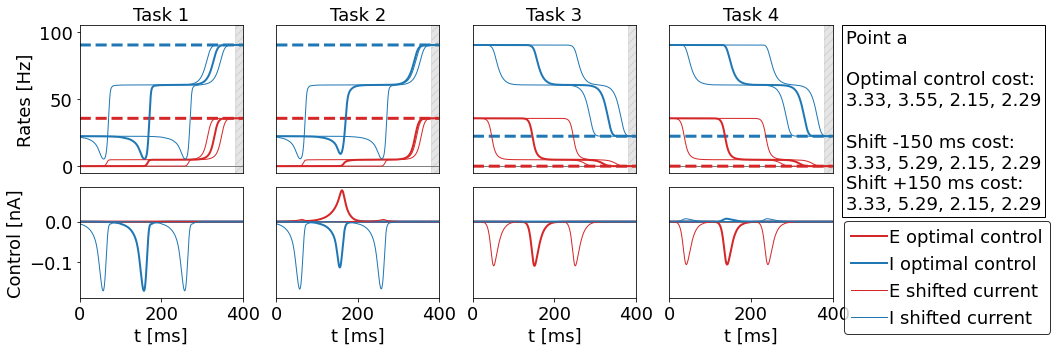

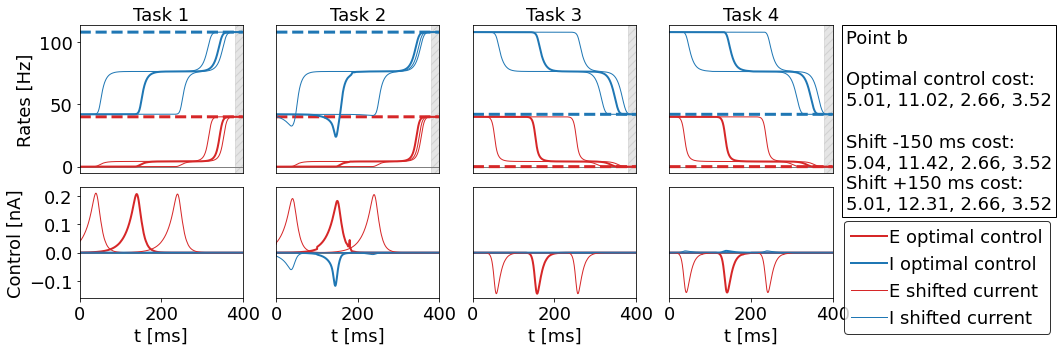

In [202]:
y_labelbox = 0.4
data.set_parameters(aln)
aln.params.mue_ext_mean = ext_exc[20] * 5.
aln.params.mui_ext_mean = ext_inh[20] * 5.

plot_control_current(aln, [ [opt_cntrl_1, opt_cntrl_min[0][0][:,:,100:-100], opt_cntrl_plus[0][0][:,:,100:-100]],
                            [opt_cntrl_2, opt_cntrl_min[1][0][:,:,100:-100], opt_cntrl_plus[1][0][:,:,100:-100]],
                            [opt_cntrl_3, opt_cntrl_min[2][0][:,:,100:-100], opt_cntrl_plus[2][0][:,:,100:-100]],
                            [opt_cntrl_4, opt_cntrl_min[3][0][:,:,100:-100], opt_cntrl_plus[3][0][:,:,100:-100]] ],
            t_sim, y_labelbox,
            [initVars_1, initVars_1, initVars_3, initVars_3], [target_1, target_1, target_3, target_3],
            label_shift_a, ['E optimal control', 'I optimal control', 'E shifted current', 'I shifted current'],
            path_=os.getcwd(), filename_ = 'Shift150_a.png', shading = False, transition_time_ = 0.95,
            precision_variables_ = [0], print_cost_ = False)
plt.show()

data.set_parameters(aln)
aln.params.mue_ext_mean = ext_exc[50] * 5.
aln.params.mui_ext_mean = ext_inh[50] * 5.

plot_control_current(aln, [ [opt_cntrl_1b, opt_cntrl_min[0][1][:,:,100:-100], opt_cntrl_plus[0][1][:,:,100:-100]],
                            [opt_cntrl_2b, opt_cntrl_min[1][1][:,:,100:-100], opt_cntrl_plus[1][1][:,:,100:-100]],
                            [opt_cntrl_3b, opt_cntrl_min[2][1][:,:,100:-100], opt_cntrl_plus[2][1][:,:,100:-100]],
                            [opt_cntrl_4b, opt_cntrl_min[3][1][:,:,100:-100], opt_cntrl_plus[3][1][:,:,100:-100]] ],
            t_sim, y_labelbox,
            [initVars_1b, initVars_1b, initVars_3b, initVars_3b], [target_1b, target_1b, target_3b, target_3b],
            label_shift_b, ['E optimal control', 'I optimal control', 'E shifted current', 'I shifted current'],
            path_=os.getcwd(), filename_ = 'Shift150_b.png', shading = False, transition_time_ = 0.95,
            precision_variables_ = [0], print_cost_ = False)
plt.show()

In [199]:
ind0 = [20, 50]
tasks = ['task1', 'task2', 'task3', 'task4']

opt_cntrl_min = [[None, None], [None, None], [None, None], [None, None]]
cost_node_min = [[None, None], [None, None], [None, None], [None, None]]

opt_cntrl_plus = [[None, None], [None, None], [None, None], [None, None]]
cost_node_plus = [[None, None], [None, None], [None, None], [None, None]]

for task_ind in range(len(tasks)):
    task = tasks[task_ind]

    readpath = '..' + os.sep + 'data_shift' + os.sep + task + os.sep + 'shift_-20'
    control_data = data.read_control(readpath, '')
    for j in range(len(ind0)):
        opt_cntrl_min[task_ind][j] = control_data[2][ind0[j]]
        cost_node_min[task_ind][j] = control_data[4][ind0[j]]
        
    readpath = '..' + os.sep + 'data_shift' + os.sep + task + os.sep + 'shift_+20'
    control_data = data.read_control(readpath, '')
    for j in range(len(ind0)):
        opt_cntrl_plus[task_ind][j] = control_data[2][ind0[j]]
        cost_node_plus[task_ind][j] = control_data[4][ind0[j]]

min_cost1a = cost_node_min[0][0][0][0,0] + cost_node_min[0][0][2][0,0] + cost_node_min[0][0][2][0,1]
min_cost2a = cost_node_min[1][0][0][0,0] + cost_node_min[1][0][1][0,0] + cost_node_min[1][0][1][0,1]
min_cost3a = cost_node_min[2][0][0][0,0] + cost_node_min[2][0][2][0,0] + cost_node_min[2][0][2][0,1]
min_cost4a = cost_node_min[3][0][0][0,0] + cost_node_min[3][0][1][0,0] + cost_node_min[3][0][1][0,1]

plus_cost1a = cost_node_plus[0][0][0][0,0] + cost_node_plus[0][0][2][0,0] + cost_node_plus[0][0][2][0,1]
plus_cost2a = cost_node_plus[1][0][0][0,0] + cost_node_plus[1][0][1][0,0] + cost_node_plus[1][0][1][0,1]
plus_cost3a = cost_node_plus[2][0][0][0,0] + cost_node_plus[2][0][2][0,0] + cost_node_plus[2][0][2][0,1]
plus_cost4a = cost_node_plus[3][0][0][0,0] + cost_node_plus[3][0][1][0,0] + cost_node_plus[3][0][1][0,1]

label_shift_a =( 'Point a \n\n' + 'Optimal control cost: \n{:.2f}'.format(opt_cost1) + ', {:.2f}'.format(opt_cost2) + ', {:.2f}'.format(opt_cost3) + ', {:.2f}'.format(opt_cost4)
            + '\n\nShift -20 ms cost: \n{:.2f}'.format(min_cost1a) + ', {:.2f}'.format(min_cost2a) + ', {:.2f}'.format(min_cost3a) + ', {:.2f}'.format(min_cost4a) 
            + '\nShift +20 ms cost: \n{:.2f}'.format(plus_cost1a) + ', {:.2f}'.format(plus_cost2a) + ', {:.2f}'.format(plus_cost3a) + ', {:.2f}'.format(plus_cost4a) )

min_cost1b = cost_node_min[0][1][0][0,0] + cost_node_min[0][1][2][0,0] + cost_node_min[0][1][2][0,1]
min_cost2b = cost_node_min[1][1][0][0,0] + cost_node_min[1][1][1][0,0] + cost_node_min[1][1][1][0,1]
min_cost3b = cost_node_min[2][1][0][0,0] + cost_node_min[2][1][2][0,0] + cost_node_min[2][1][2][0,1]
min_cost4b = cost_node_min[3][1][0][0,0] + cost_node_min[3][1][1][0,0] + cost_node_min[3][1][1][0,1]

plus_cost1b = cost_node_plus[0][1][0][0,0] + cost_node_plus[0][1][2][0,0] + cost_node_plus[0][1][2][0,1]
plus_cost2b = cost_node_plus[1][1][0][0,0] + cost_node_plus[1][1][1][0,0] + cost_node_plus[1][1][1][0,1]
plus_cost3b = cost_node_plus[2][1][0][0,0] + cost_node_plus[2][1][2][0,0] + cost_node_plus[2][1][2][0,1]
plus_cost4b = cost_node_plus[3][1][0][0,0] + cost_node_plus[3][1][1][0,0] + cost_node_plus[3][1][1][0,1]

label_shift_b =( 'Point b \n\n' + 'Optimal control cost: \n{:.2f}'.format(opt_cost1b) + ', {:.2f}'.format(opt_cost2b) + ', {:.2f}'.format(opt_cost3b) + ', {:.2f}'.format(opt_cost4b)
            + '\n\nShift -20 ms cost: \n{:.2f}'.format(min_cost1b) + ', {:.2f}'.format(min_cost2b) + ', {:.2f}'.format(min_cost3b) + ', {:.2f}'.format(min_cost4b) 
            + '\nShift +20 ms cost: \n{:.2f}'.format(plus_cost1b) + ', {:.2f}'.format(plus_cost2b) + ', {:.2f}'.format(plus_cost3b) + ', {:.2f}'.format(plus_cost4b) )

case =  ../data_shift/task1/shift_-20 
case =  ../data_shift/task1/shift_+20 
case =  ../data_shift/task2/shift_-20 
case =  ../data_shift/task2/shift_+20 
case =  ../data_shift/task3/shift_-20 
case =  ../data_shift/task3/shift_+20 
case =  ../data_shift/task4/shift_-20 
case =  ../data_shift/task4/shift_+20 


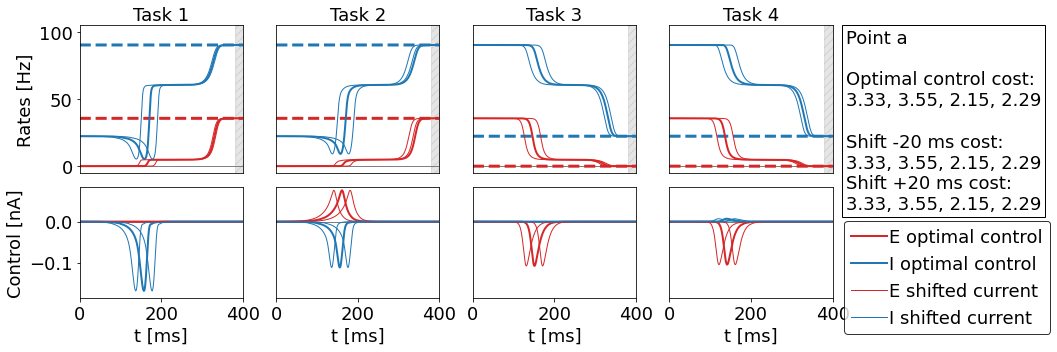

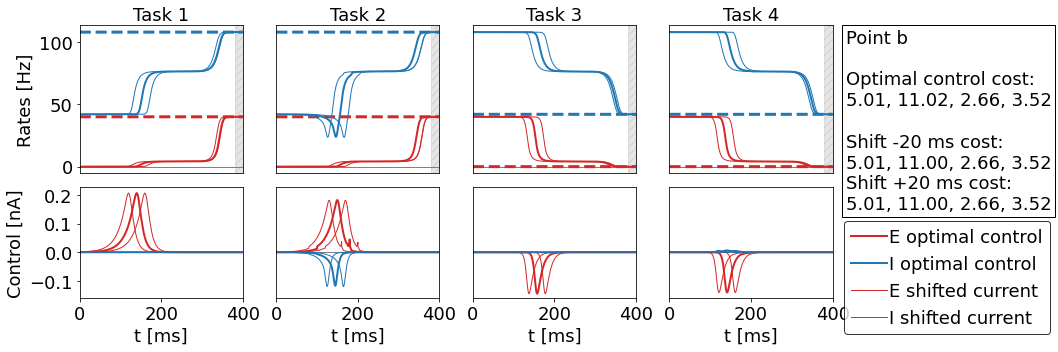

In [200]:
y_labelbox = 0.4
data.set_parameters(aln)
aln.params.mue_ext_mean = ext_exc[20] * 5.
aln.params.mui_ext_mean = ext_inh[20] * 5.

plot_control_current(aln, [ [opt_cntrl_1, opt_cntrl_min[0][0][:,:,100:-100], opt_cntrl_plus[0][0][:,:,100:-100]],
                            [opt_cntrl_2, opt_cntrl_min[1][0][:,:,100:-100], opt_cntrl_plus[1][0][:,:,100:-100]],
                            [opt_cntrl_3, opt_cntrl_min[2][0][:,:,100:-100], opt_cntrl_plus[2][0][:,:,100:-100]],
                            [opt_cntrl_4, opt_cntrl_min[3][0][:,:,100:-100], opt_cntrl_plus[3][0][:,:,100:-100]] ],
            t_sim, y_labelbox,
            [initVars_1, initVars_1, initVars_3, initVars_3], [target_1, target_1, target_3, target_3],
            label_shift_a, ['E optimal control', 'I optimal control', 'E shifted current', 'I shifted current'],
            path_=os.getcwd(), filename_ = 'Shift20_a.png', shading = False, transition_time_ = 0.95,
            precision_variables_ = [0], print_cost_ = False)
plt.show()

data.set_parameters(aln)
aln.params.mue_ext_mean = ext_exc[50] * 5.
aln.params.mui_ext_mean = ext_inh[50] * 5.

plot_control_current(aln, [ [opt_cntrl_1b, opt_cntrl_min[0][1][:,:,100:-100], opt_cntrl_plus[0][1][:,:,100:-100]],
                            [opt_cntrl_2b, opt_cntrl_min[1][1][:,:,100:-100], opt_cntrl_plus[1][1][:,:,100:-100]],
                            [opt_cntrl_3b, opt_cntrl_min[2][1][:,:,100:-100], opt_cntrl_plus[2][1][:,:,100:-100]],
                            [opt_cntrl_4b, opt_cntrl_min[3][1][:,:,100:-100], opt_cntrl_plus[3][1][:,:,100:-100]] ],
            t_sim, y_labelbox,
            [initVars_1b, initVars_1b, initVars_3b, initVars_3b], [target_1b, target_1b, target_3b, target_3b],
            label_shift_b, ['E optimal control', 'I optimal control', 'E shifted current', 'I shifted current'],
            path_=os.getcwd(), filename_ = 'Shift20_b.png', shading = False, transition_time_ = 0.95,
            precision_variables_ = [0], print_cost_ = False)
plt.show()